# Lab 27 — Inside an LTE/NR Downlink: Resource Grid, Cell Search and the PDSCH Chain with HARQ

**Companion to Chapter 21** (*Cellular Generations: AMPS to 5G*). Lab 11 computes the system-level numbers of LTE and NR;
this lab builds the physical layer itself, bit by bit.
**Time needed:** about 2 hours. **Difficulty:** advanced.

When a phone is switched on it knows nothing: not the timing, not the frequency error of its own crystal, not which of 504
cells it is hearing. Within a few hundred milliseconds it has found the strongest cell, locked to its 1 ms subframes, read its
identity and is ready to decode data protected by a CRC, an LDPC code, rate matching, scrambling, QAM and OFDM, with hybrid
ARQ quietly combining retransmissions underneath. This lab does all of it in about two hundred lines, using the new module
`commlib/ltephy.py`. The grid, the synchronisation signals and the reference signals are LTE's (TS 36.211) on a 1.4 MHz
carrier; the channel coding is NR-flavoured (LDPC with a circular buffer and four redundancy versions, TS 38.212), with
commlib's PEG LDPC code standing in for the NR base graphs.

### What you will learn
1. Read an LTE subframe: control region, cell-specific reference signals, PSS and SSS, data; count resource elements and overhead.
2. Generate the Zadoff–Chu PSS and m-sequence SSS and see why their correlation properties make cell search work.
3. Find two cells in a noisy, frequency-offset signal: timing, frequency offset and the 504 physical cell identities.
4. Build the PDSCH chain: CRC24A, code-block segmentation with CRC24B, LDPC, circular-buffer rate matching, interleaving,
   scrambling, QAM, resource mapping and OFDM, and the receiver that undoes it with CRS channel estimation.
5. Measure BLER for several modulation and coding schemes, and the gain of HARQ with incremental redundancy over chase combining.

### Prerequisites
Lab 7 (OFDM), Lab 4 (synchronisation), Lab 9 (LDPC), Lab 20 (CRCs). Chapter 21, with Chapters 10, 15 and 17 for background.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | The LTE resource grid and its overhead | yes |
| 2 | PSS and SSS: Zadoff–Chu and m-sequences | |
| 3 | Cell search on a two-cell signal | yes |
| 4 | The PDSCH transmitter and receiver | yes |
| 5 | BLER versus SNR for several MCS | |
| 6 | HARQ: chase combining versus incremental redundancy | |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import commlib as cl
from commlib import ltephy as lp
from commlib import ofdm as co
from commlib import labkit as lk

rng = lk.setup(seed=27, lab="27")

Lab 27 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 27


## 1. The LTE resource grid and its overhead

An LTE carrier of $N_{RB}$ resource blocks has $12N_{RB}$ subcarriers at 15 kHz; a 1 ms subframe has 14 OFDM symbols (normal
cyclic prefix), so one **resource element** (RE) is one subcarrier for one symbol. Here $N_{RB} = 6$ (1.4 MHz): a 128-point FFT
at 1.92 MS/s, cyclic prefixes of 10 and 9 samples, 1920 samples per subframe. Before any user data, the grid carries:
a **control region** of 1–3 symbols (PCFICH, PHICH, PDCCH); **cell-specific reference signals** (CRS) of port 0 on symbols 0
and 4 of each slot, every sixth subcarrier, shifted by $\mathrm{PCI} \bmod 6$; and in subframes 0 and 5 the **SSS** and
**PSS** on the 62 central subcarriers of the last two symbols of the first slot. Chapter 21's peak-rate example for 20 MHz,
four CRS ports and one control symbol counts 13,600 PDSCH REs per millisecond out of 16,800, a 19% overhead.

### Interactive: cell identity, subframe and control region

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

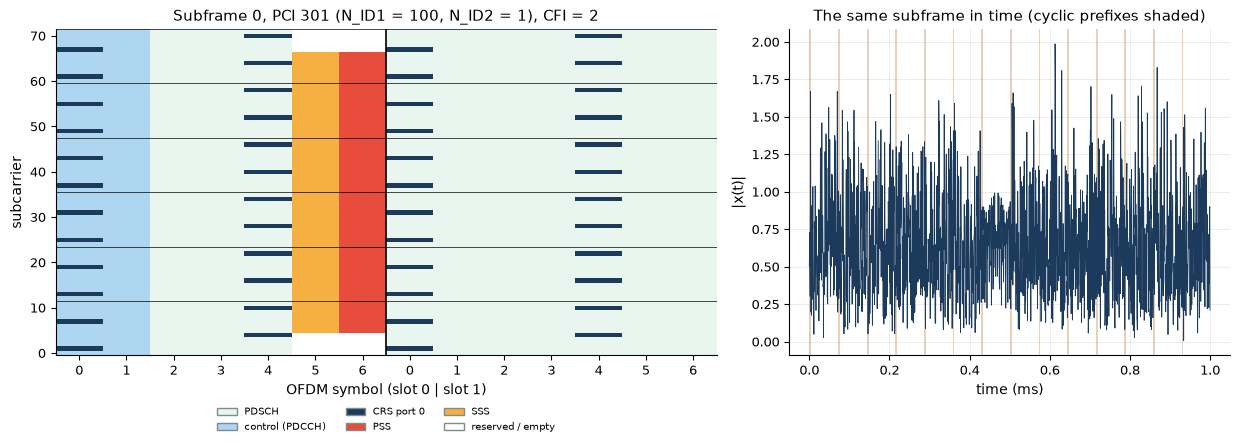

RE type,count,share
PDSCH,684,67.9%
control (PDCCH),132,13.1%
CRS port 0,48,4.8%
PSS,62,6.2%
SSS,62,6.2%
reserved / empty,20,2.0%


In [3]:
COLS = ["#E8F6EF", "#AED6F1", lk.NAVY, "#E74C3C", "#F5B041", "#FFFFFF"]
NAMES = ["PDSCH", "control (PDCCH)", "CRS port 0", "PSS", "SSS", "reserved / empty"]

def grid_demo(pci=301, subframe=0, cfi=2):
    G, lab = lp.subframe_grid(pci, subframe, np.random.default_rng(0), cfi=cfi)
    f, ax = lk.fig((12.5, 4.6), 1, 2, gridspec_kw=dict(width_ratios=[1.5, 1]))
    ax[0].imshow(lab, aspect="auto", origin="lower", cmap=ListedColormap(COLS), vmin=-0.5, vmax=5.5, interpolation="nearest",
                 extent=(-0.5, 13.5, -0.5, 71.5))
    for y in np.arange(-0.5, 72, 12):
        ax[0].axhline(y, color="k", lw=0.5)
    ax[0].axvline(6.5, color="k", lw=1.2); ax[0].grid(False)
    ax[0].set_xticks(range(14)); ax[0].set_xticklabels([str(i % 7) for i in range(14)])
    ax[0].set_xlabel("OFDM symbol (slot 0 | slot 1)"); ax[0].set_ylabel("subcarrier")
    ax[0].set_title(f"Subframe {subframe}, PCI {pci} (N_ID1 = {pci // 3}, N_ID2 = {pci % 3}), CFI = {cfi}")
    ax[0].legend(handles=[Patch(facecolor=c, edgecolor=lk.GRAY, label=n) for c, n in zip(COLS, NAMES)], fontsize=7, ncol=3,
                 loc="upper center", bbox_to_anchor=(0.5, -0.13), frameon=False)
    x = lp.ofdm_mod(G)
    t = np.arange(len(x)) / lp.FS * 1e3
    ax[1].plot(t, np.abs(x), color=lk.NAVY, lw=0.6)
    starts = np.cumsum(np.r_[0, lp.CP + lp.NFFT])[:-1] / lp.FS * 1e3
    for s_, c_ in zip(starts, lp.CP):
        ax[1].axvspan(s_, s_ + c_ / lp.FS * 1e3, color=lk.ORANGE, alpha=0.3, lw=0)
    ax[1].set_xlabel("time (ms)"); ax[1].set_ylabel("|x(t)|"); ax[1].set_title("The same subframe in time (cyclic prefixes shaded)")
    lk.show(f)
    cnt = [np.sum(lab == i) for i in range(6)]
    lk.table([[n, c, f"{100 * c / lab.size:.1f}%"] for n, c in zip(NAMES, cnt)], ["RE type", "count", "share"],
             title=f"{lab.size} REs in one subframe of 6 RBs")

lk.interact(grid_demo, pci=lk.islider(301, 0, 503, 1, "physical cell ID"), subframe=lk.islider(0, 0, 9, 1, "subframe"),
            cfi=lk.islider(2, 1, 3, 1, "control symbols (CFI)"))

**What you should see.** The CRS form a diagonal lattice (every sixth subcarrier, staggered by three between symbols 0 and 4);
change the PCI by one and the lattice shifts by one subcarrier, which is how neighbouring cells avoid putting their pilots on
top of each other. In subframe 0 the PSS (red) and SSS (orange) occupy 62 subcarriers with five empty ones on either side.
Select subframe 1 and the synchronisation signals disappear: 828 PDSCH REs with CFI = 2. The time plot shows the OFDM signal's
noise-like envelope and the slightly longer first cyclic prefix of each slot (10 samples instead of 9).

### Try it yourself 1.1
Reproduce Chapter 21's count for 20 MHz (100 RBs), one control symbol and four CRS ports (24 CRS REs per RB pair, 4 of them in
the control symbol): how many PDSCH REs per millisecond?

In [5]:
answer_1_1 = None
lk.check("1.1 PDSCH REs per ms, 20 MHz LTE", answer_1_1, 1200 * 14 - 1200 - 100 * 20, atol=0)

[TODO] 1.1 PDSCH REs per ms, 20 MHz LTE: not attempted yet: replace the None with your answer

In [6]:
rows = []
for mu in range(5):
    d = co.nr_numerology(mu)
    rows.append([mu, d["scs_khz"], 2 ** mu, 1 / 2 ** mu, f"{1e6 / (d['scs_khz'] * 1e3) * (1 + 144 / 2048):.2f}"])
lk.table(rows, ["μ", "SCS (kHz)", "slots per 1 ms", "slot (ms)", "symbol + CP (µs)"], title="NR numerologies (TS 38.211)")
nr_rate = lambda layers, Qm, nprb, mu, oh: layers * Qm * 948 / 1024 * 12 * nprb / (1e-3 / (14 * 2 ** mu)) * (1 - oh)
lk.table([["FR1: 100 MHz, 30 kHz, 4 layers, 256QAM, 14% overhead", f"{nr_rate(4, 8, 273, 1, 0.14) / 1e9:.2f} Gb/s"],
          ["FR2: 400 MHz, 120 kHz, 2 layers, 64QAM, 18% overhead", f"{nr_rate(2, 6, 264, 3, 0.18) / 1e9:.2f} Gb/s"]],
         ["Chapter 21: NR peak rates (TS 38.306 formula)", ""])

μ,SCS (kHz),slots per 1 ms,slot (ms),symbol + CP (µs)
0,15,1,1,71.35
1,30,2,0.5,35.68
2,60,4,0.25,17.84
3,120,8,0.125,8.92
4,240,16,0.0625,4.46


Chapter 21: NR peak rates (TS 38.306 formula),
"FR1: 100 MHz, 30 kHz, 4 layers, 256QAM, 14% overhead",2.34 Gb/s
"FR2: 400 MHz, 120 kHz, 2 layers, 64QAM, 18% overhead",3.23 Gb/s


**What you should see.** The numerology table: each step of μ doubles the subcarrier spacing and halves the slot. The NR peak-rate
formula reproduces Chapter 21's worked example: about 2.34 Gb/s for a 100 MHz FR1 carrier with four layers and 256QAM, and
about 3.23 Gb/s for a 400 MHz FR2 carrier with two layers.

## 2. PSS and SSS: Zadoff–Chu and m-sequences

The **PSS** is one of three length-63 Zadoff–Chu sequences (roots $u = 25, 29, 34$, the middle element punctured for DC),
selected by $N_{ID}^{(2)} \in \{0,1,2\}$. Zadoff–Chu sequences have constant amplitude and an ideal periodic autocorrelation,
and different roots have low cross-correlation, so a receiver can correlate the incoming samples with three short waveforms
without knowing anything else. The **SSS** interleaves two length-31 m-sequences, cyclically shifted according to
$N_{ID}^{(1)} \in \{0..167\}$ and scrambled by sequences that depend on $N_{ID}^{(2)}$; the order of the two halves is swapped
between subframes 0 and 5, which reveals the 10 ms frame boundary. Together: $\mathrm{PCI} = 3N_{ID}^{(1)} + N_{ID}^{(2)}$, 504 identities.

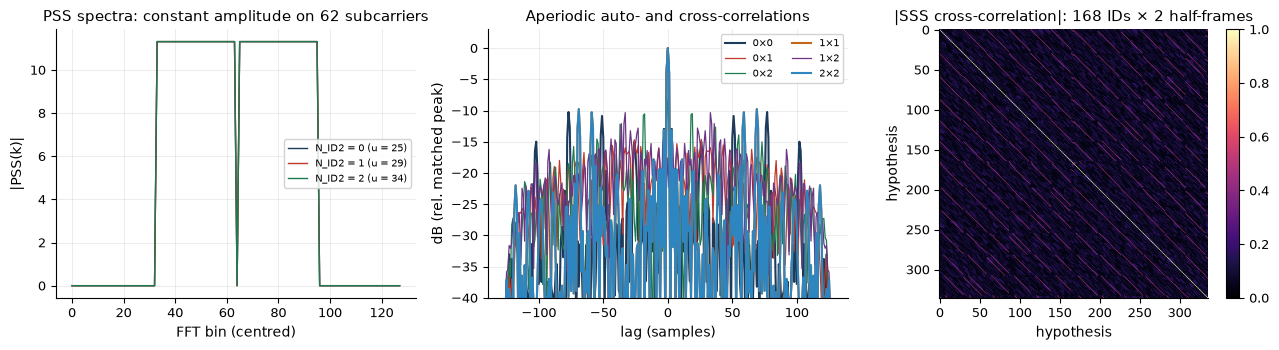

sequence property,value
PSS: max cross-correlation between roots,-8.3 dB
SSS: max |correlation| between different hypotheses,0.48
SSS: mean |correlation|,0.086


In [8]:
P = lp.pss_waveforms()
f, ax = lk.fig((13, 3.6), 1, 3)
for i in range(3):
    ax[0].plot(np.abs(np.fft.fftshift(np.fft.fft(P[i]))), lw=1, label=f"N_ID2 = {i} (u = {lp.PSS_ROOTS[i]})")
ax[0].set_xlabel("FFT bin (centred)"); ax[0].set_ylabel("|PSS(k)|"); ax[0].set_title("PSS spectra: constant amplitude on 62 subcarriers"); ax[0].legend(fontsize=7)
lags = np.arange(-127, 128)
for i in range(3):
    for j in range(3):
        c = np.abs(np.correlate(P[i], P[j], "full")) / 62               # matched peak = PSS energy = 62
        if i <= j:
            ax[1].plot(lags, lk.db(c ** 2), lw=0.9 if i != j else 1.5, label=f"{i}×{j}", color=lk.PALETTE[3 * i + j - (i * (i + 1)) // 2])
ax[1].set_xlabel("lag (samples)"); ax[1].set_ylabel("dB (rel. matched peak)"); ax[1].set_ylim(-40, 3); ax[1].legend(fontsize=7, ncol=2)
ax[1].set_title("Aperiodic auto- and cross-correlations")
S = np.array([lp.sss_sequence(n1, 0, 0) for n1 in range(168)] + [lp.sss_sequence(n1, 0, 5) for n1 in range(168)])
Cm = np.abs(S @ S.T) / 62
im = ax[2].imshow(Cm, cmap="magma", vmin=0, vmax=1); ax[2].grid(False); plt.colorbar(im, ax=ax[2])
ax[2].set_title("|SSS cross-correlation|: 168 IDs × 2 half-frames"); ax[2].set_xlabel("hypothesis"); ax[2].set_ylabel("hypothesis")
lk.show(f)
off = Cm[~np.eye(336, dtype=bool)]
lk.table([["PSS: max cross-correlation between roots", f"{lk.db(max(np.abs(np.correlate(P[i], P[j], 'full')).max() for i in range(3) for j in range(3) if i != j) ** 2 / (62 / 128 * 128) ** 2):.1f} dB"],
          ["SSS: max |correlation| between different hypotheses", f"{off.max():.2f}"], ["SSS: mean |correlation|", f"{off.mean():.3f}"]],
         ["sequence property", "value"])

**What you should see.** All three PSS spectra are flat (constant-amplitude Zadoff–Chu). The autocorrelations have a single
sharp peak; the cross-correlations stay at least about 8 dB below it at every lag, so a receiver can tell the three roots
apart even before it knows the timing. The SSS matrix is a bright diagonal on a dark background: 336 nearly orthogonal
hypotheses (some pairs reach about 0.5, which is why the SSS needs a few dB more SNR than its length alone suggests).

## 3. Cell search on a two-cell signal

Chapter 21's simulation problem: a phone receives cell A and a second cell B 6 dB weaker, each with its own timing, a common
frequency offset from the phone's crystal, and noise. The search runs in three steps (Chapter 10, Section 10.6):
1. **PSS**: correlate with the three PSS waveforms; a peak gives $N_{ID}^{(2)}$ and the symbol timing. The PSS repeats every
   5 ms, so the correlation energy is folded and **averaged over several half-frames**: against a strong neighbour, whose data
   look like noise to the weak cell's PSS, a single half-frame is not enough. A frequency offset of a few kHz rotates the phase
   across the 67 µs PSS symbol and destroys a coherent correlation, so the correlation is split into segments combined
   non-coherently; the phase between the segments estimates the offset.
2. **CFO**: $\hat f = \angle(c_2 c_1^*)/(2\pi \cdot 64/f_s)$ for two halves, unambiguous to ±15 kHz.
3. **SSS**: remove the offset, use the PSS as a channel estimate, and correlate the SSS with the 2 × 168 hypotheses (again
   accumulated over the half-frames, with the two SSS versions alternating): the winner gives $N_{ID}^{(1)}$, the PCI and the
   half-frame.

### Interactive: the two-cell search

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

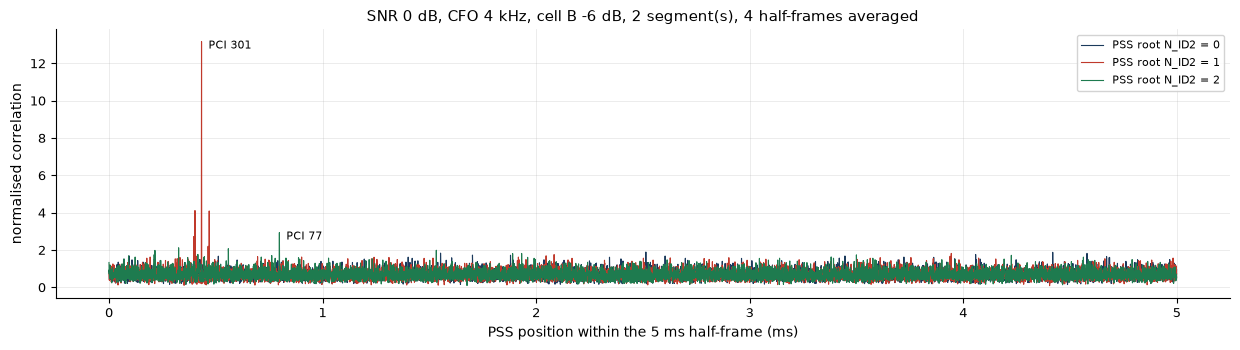

detected PCI,correct?,PSS sample,CFO estimate (kHz)
301,yes,832,4.31
77,yes,1532,4.31


In [10]:
PCI_A, PCI_B = 301, 77
HF = 9600                                                  # samples per 5 ms half-frame
def cell_waveform(pci, seed=0):
    """Four 10 ms frames of a fully loaded cell (independent random data in every subframe)."""
    r = np.random.default_rng(seed)
    return lp.ofdm_mod(np.array([lp.subframe_grid(pci, sf % 10, r)[0] for sf in range(40)]))
WAVES = {pci: cell_waveform(pci, seed=pci) for pci in (PCI_A, PCI_B)}

def two_cell_rx(snr_db, cfo_hz, rel_db, delayA, delayB, r, n_hf=4):
    n = (n_hf + 1) * HF + 2 * lp.NFFT
    y = np.zeros(n, complex)
    for pci, d, g in [(PCI_A, delayA, 1.0), (PCI_B, delayB, 10 ** (rel_db / 20))]:
        h = np.exp(2j * np.pi * r.random())                  # random carrier phase per cell
        y += g * h * WAVES[pci][2 * HF - d:2 * HF - d + n]     # start mid-frame: the search must find the timing
    y *= np.exp(2j * np.pi * cfo_hz * np.arange(n) / lp.FS)
    s2 = 72 / 128 * lk.undb(-snr_db)                         # SNR defined over the 1.08 MHz occupied band
    return y + np.sqrt(s2 / 2) * (r.standard_normal(n) + 1j * r.standard_normal(n))

def cell_search(y, halves=2, n_cells=2, n_hf=4):
    m, seg = lp.pss_search(y[:n_hf * HF + lp.NFFT], halves)
    mf = sum(m[:, k * HF:(k + 1) * HF] for k in range(n_hf)) / n_hf      # fold onto one half-frame
    found = []
    mm = mf.copy()
    for _ in range(n_cells):
        i, t = np.unravel_index(np.argmax(mm), mm.shape)
        if found:                                              # the offset is the phone's own crystal: common to all cells
            cfo = found[0]["cfo"]
        elif halves > 1:
            prod = sum(np.sum(seg[i, 1:, t + k * HF] * np.conj(seg[i, :-1, t + k * HF])) for k in range(n_hf))
            cfo = np.angle(prod) / (2 * np.pi * (lp.NFFT // halves) / lp.FS)
        else:
            cfo = 0.0
        acc = np.zeros((2, 168))
        for k in range(1, n_hf + 1):                           # SSS precedes the PSS: start from the second copy
            _, _, mk = lp.sss_detect(y, t + k * HF, i, cfo)
            acc += mk if k % 2 else mk[::-1]
        sf_i, n1 = np.unravel_index(np.argmax(acc), acc.shape)
        found.append(dict(pci=3 * int(n1) + int(i), t=int(t), cfo=cfo, sf=(5, 0)[sf_i], metric=float(mf[i, t])))
        mm[i, (t + np.arange(-200, 200)) % HF] = 0             # suppress this peak (circularly)
    return found, mf

def search_demo(snr_db=0.0, cfo_khz=4.0, rel_db=-6.0, halves=2, n_hf=4):
    r = np.random.default_rng(5)
    y = two_cell_rx(snr_db, cfo_khz * 1e3, rel_db, 0, 700, r, n_hf)
    found, m = cell_search(y, halves, n_hf=n_hf)
    f, ax = lk.fig((12.5, 3.6))
    t = np.arange(m.shape[1]) / lp.FS * 1e3
    for i in range(3):
        ax.plot(t, m[i], lw=0.8, label=f"PSS root N_ID2 = {i}")
    for c in found:
        ax.annotate(f"PCI {c['pci']}", (c["t"] / lp.FS * 1e3, c["metric"]), (5, -5), textcoords="offset points", fontsize=8)
    ax.set_xlabel("PSS position within the 5 ms half-frame (ms)"); ax.set_ylabel("normalised correlation"); ax.legend(fontsize=8)
    ax.set_title(f"SNR {snr_db:g} dB, CFO {cfo_khz:g} kHz, cell B {rel_db:g} dB, {halves} segment(s), {n_hf} half-frames averaged")
    lk.show(f)
    truth = {PCI_A, PCI_B}
    lk.table([[c["pci"], "yes" if c["pci"] in truth else "NO", c["t"], f"{c['cfo'] / 1e3:.2f}"] for c in found],
             ["detected PCI", "correct?", "PSS sample", "CFO estimate (kHz)"], title=f"true cells: {PCI_A} (A) and {PCI_B} (B); true CFO {cfo_khz:g} kHz")

lk.interact(search_demo, snr_db=lk.slider(0, -15, 20, 1, "SNR (dB)"), cfo_khz=lk.slider(4, -12, 12, 0.5, "frequency offset (kHz)"),
            rel_db=lk.slider(-6, -15, 0, 1, "cell B relative power (dB)"), halves=lk.choice([1, 2, 4], 2, "coherent segments"),
            n_hf=lk.choice([1, 2, 4], 4, "half-frames averaged"))

**What you should see.** Two peaks: the taller for cell A (PCI 301, $N_{ID}^{(2)} = 1$), the other 700 samples later for cell B
(PCI 77, $N_{ID}^{(2)} = 2$). Both PCIs are found and the CFO is estimated to within a few hundred hertz. Now set
*half-frames averaged* to 1: cell B's peak sinks into the fluctuations of cell A's data and the search returns a wrong PCI. Set
*coherent segments* to 1 with a large offset (say 8 kHz): the phase rotates by about 190° across the PSS and the coherent peak collapses.

The detection probability of both cells against SNR, with and without the split correlation (four half-frames averaged):

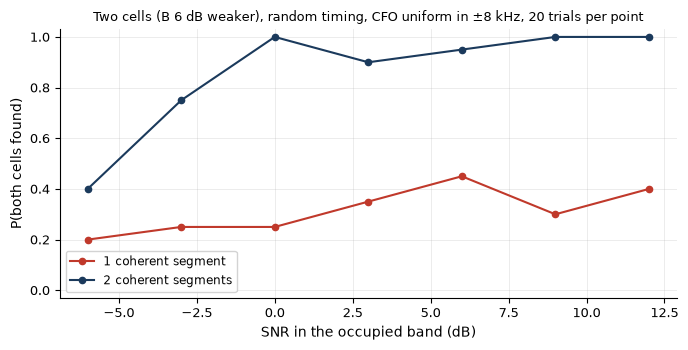

SNR (dB),1 segment,2 segments
-6,0.20,0.40
-3,0.25,0.75
+0,0.25,1.00
+3,0.35,0.90
+6,0.45,0.95
+9,0.30,1.00
+12,0.40,1.00


In [12]:
snrs = np.arange(-6, 13, 3)
res = {}
for halves in (1, 2):
    pd = []
    for s in snrs:
        r = np.random.default_rng(int(100 + s))
        ok = 0
        for trial in range(20):
            y = two_cell_rx(s, r.uniform(-8e3, 8e3), -6.0, r.integers(0, HF), r.integers(0, HF), r)
            found, _ = cell_search(y, halves)
            ok += {c["pci"] for c in found} == {PCI_A, PCI_B}
        pd.append(ok / 20)
    res[halves] = pd
f, ax = lk.fig((7, 3.6))
for h, col in [(1, lk.RED), (2, lk.NAVY)]:
    ax.plot(snrs, res[h], "o-", color=col, label=f"{h} coherent segment{'s' if h > 1 else ''}")
ax.set_xlabel("SNR in the occupied band (dB)"); ax.set_ylabel("P(both cells found)"); ax.set_ylim(-0.03, 1.03); ax.legend()
ax.set_title("Two cells (B 6 dB weaker), random timing, CFO uniform in ±8 kHz, 20 trials per point", fontsize=9)
lk.show(f)
lk.table([[f"{s_:+d}", f"{a_:.2f}", f"{b_:.2f}"] for s_, a_, b_ in zip(snrs, res[1], res[2])], ["SNR (dB)", "1 segment", "2 segments"])

**What you should see.** With the split correlation, both cells are found almost always from about 0 dB
(cell B then faces about −6 dB of interference from cell A's data as well as the noise); the single coherent correlation loses
trials whenever the random offset is large. The frequency offset is estimated once, on the strongest cell, and reused for the
others: it is the phone's own crystal error, common to every cell. Real phones combine these tricks with several frequency hypotheses.

### Try it yourself 3.1
What PCI has $N_{ID}^{(1)} = 25$ and $N_{ID}^{(2)} = 2$?

In [14]:
answer_3_1 = None
lk.check("3.1 PCI from N_ID1 = 25, N_ID2 = 2", answer_3_1, 77, atol=0)

[TODO] 3.1 PCI from N_ID1 = 25, N_ID2 = 2: not attempted yet: replace the None with your answer

## 4. The PDSCH transmitter and receiver

One transport block (TB) per subframe on all 6 RBs of subframe 1, CFI = 2: 828 PDSCH REs. The chain (TS 38.212 / 36.211):
1. **CRC24A** on the TB; **segmentation** into $C$ code blocks of 360 bits, each with its own **CRC24B** (so the receiver can
   stop early and HARQ can report per code block).
2. **LDPC** encoding of each 384-bit block into 1152 bits (mother rate 1/3); write systematic bits first into a **circular
   buffer** of $N_{cb} = 1152$.
3. **Rate matching**: read $E = 828 Q_m / C$ bits starting at $k_0(\mathrm{rv}) = \{0, 17, 33, 56\}/66 \cdot N_{cb}$, wrapping
   around (repetition) if $E > N_{cb}$. Then the row–column **bit interleaver** (so each QAM symbol mixes bits of different reliability).
4. **Scrambling** with the length-31 Gold sequence, $c_{init} = n_{RNTI}2^{14} + q2^{13} + \lfloor n_s/2\rfloor 2^9 + N_{ID}^{cell}$.
5. **QAM** mapping (Gray, commlib's labelling), mapping to the PDSCH REs around the CRS, **OFDM**.

The receiver estimates the channel from the CRS (least squares at the pilots, linear interpolation in frequency and time),
equalises, computes max-log LLRs, descrambles, de-interleaves, accumulates the LLRs into each code block's soft circular buffer,
runs a batched min-sum LDPC decoder and checks the CRCs.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

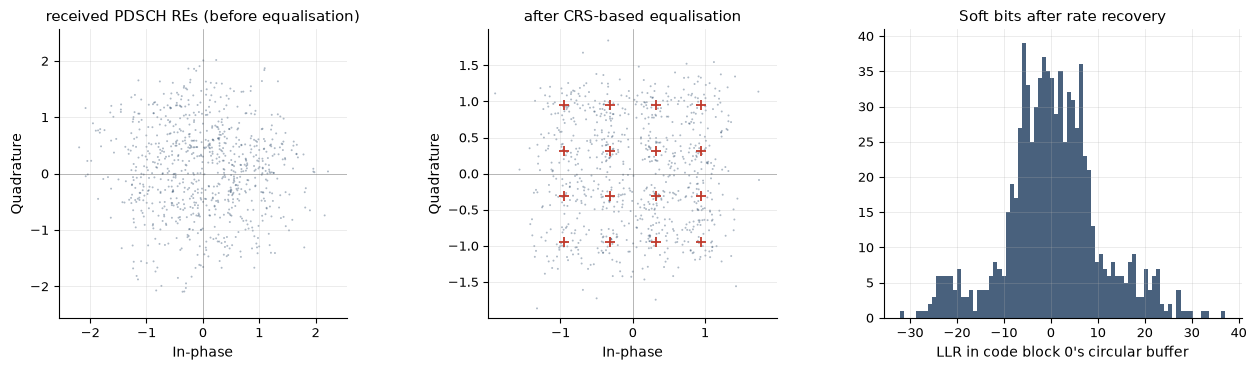

,
transport block size,1416 bits (1.42 Mb/s at one TB per ms)
code blocks C × payload,4 × 360 + CRC24B
coded bits per code block E,828
effective code rate K/E,0.464
PDSCH REs × Qm,828 × 4 = 3312
code-block CRCs,ok ok ok ok
LDPC iterations used,6 4 3 6
transport-block CRC24A,PASS
bit errors in TB,0


In [16]:
CODE = cl.LDPCCode(n=1152, rate=1 / 3, seed=1)              # k = 384
KCB = CODE.k - 24                                          # 360 payload bits per code block
PCI, SF, CFI, RNTI = 301, 1, 2, 0x1234
MASK = lp.pdsch_re_mask(PCI, SF, CFI)
NRE = int(MASK.sum())
MCS = {"QPSK, R≈0.23 (1 CB)": (2, 1), "QPSK, R≈0.46 (2 CBs)": (2, 2), "16QAM, R≈0.46 (4 CBs)": (4, 4),
       "64QAM, R≈0.46 (6 CBs)": (6, 6), "QPSK, R≈0.70 (3 CBs)": (2, 3), "64QAM, R≈0.70 (9 CBs)": (6, 9)}
CON = {2: cl.get_constellation("qpsk"), 4: cl.get_constellation("16qam"), 6: cl.get_constellation("64qam")}
SCR = lp.gold_sequence(RNTI * 2 ** 14 + (2 * SF // 2) * 2 ** 9 + PCI, NRE * 6)
INFO, PIV = CODE.info, CODE.pivots

def tb_size(C):
    return C * KCB - 24

def pdsch_encode(tb, Qm, C):
    """TB bits -> (list of circular buffers (C, Ncb), E per code block)."""
    a = lp.crc_attach(tb, lp.CRC24A)
    blocks = np.array([lp.crc_attach(a[c * KCB:(c + 1) * KCB], lp.CRC24B) for c in range(C)])
    cw = CODE.encode(blocks).reshape(C, -1)
    return np.concatenate([cw[:, INFO], cw[:, PIV]], axis=1), NRE * Qm // C

def pdsch_modulate(cbufs, E, Qm, rv):
    e = np.concatenate([lp.bit_interleave(lp.rate_match(cb, E, rv), Qm) for cb in cbufs])
    sym = CON[Qm].modulate(e ^ SCR[:len(e)])
    G, _ = lp.subframe_grid(PCI, SF, np.random.default_rng(1), cfi=CFI, data=sym)
    return G

def channel(x, snr_db, profile, r):
    y = x if profile == "AWGN" else cl.tdl_channel(x, lp.FS, profile, fd_hz=5.0, rng=r)[:len(x)]
    n0 = lk.undb(-snr_db)                                   # per-RE SNR: Es = 1 on every subcarrier
    return y + np.sqrt(n0 / 2) * (r.standard_normal(len(y)) + 1j * r.standard_normal(len(y))), n0

def pdsch_demod(y, n0, Qm, C, E, rv, soft=None, perfect_H=None):
    Y = lp.ofdm_demod(y)
    H = lp.crs_channel_estimate(Y, PCI, SF) if perfect_H is None else perfect_H
    llr = CON[Qm].llr(Y[MASK], n0, h=H[MASK])
    llr = llr * (1 - 2.0 * SCR[:len(llr)])                  # descramble: flip LLR signs where c = 1
    soft = np.zeros((C, CODE.n)) if soft is None else soft
    for c in range(C):
        soft[c] = lp.rate_recover(lp.bit_deinterleave(llr[c * E:(c + 1) * E], Qm), CODE.n, rv, soft[c])
    return soft, Y, H

def pdsch_decode(soft, C, iters=25):
    lcw = np.empty_like(soft)
    lcw[:, INFO], lcw[:, PIV] = soft[:, :CODE.k], soft[:, CODE.k:]
    d, used = lp.ldpc_decode_batch(CODE, lcw, iters=iters)
    blocks = d[:, INFO]
    cb_ok = np.array([lp.crc_ok(b, lp.CRC24B) for b in blocks])
    a = np.concatenate([b[:KCB] for b in blocks])
    return a[:-24], cb_ok, lp.crc_ok(a, lp.CRC24A), used

def chain_demo(mcs="16QAM, R≈0.46 (4 CBs)", snr_db=12.0, profile="EVA"):
    Qm, C = MCS[mcs]
    r = np.random.default_rng(11)
    tb = r.integers(0, 2, tb_size(C)).astype(np.int8)
    cbufs, E = pdsch_encode(tb, Qm, C)
    x = lp.ofdm_mod(pdsch_modulate(cbufs, E, Qm, 0))
    y, n0 = channel(x, snr_db, profile, r)
    soft, Y, H = pdsch_demod(y, n0, Qm, C, E, 0)
    dec, cb_ok, tb_ok, used = pdsch_decode(soft.copy(), C)
    f, ax = lk.fig((13, 3.8), 1, 3)
    lk.constellation(ax[0], Y[MASK], None, "received PDSCH REs (before equalisation)", s=2)
    lk.constellation(ax[1], Y[MASK] / H[MASK], CON[Qm].points, "after CRS-based equalisation", s=2)
    ax[2].hist(soft[0][soft[0] != 0], bins=80, color=lk.NAVY, alpha=0.8)
    ax[2].set_xlabel("LLR in code block 0's circular buffer"); ax[2].set_title("Soft bits after rate recovery")
    lk.show(f)
    lk.table([["transport block size", f"{len(tb)} bits ({len(tb) / 1e3:.2f} Mb/s at one TB per ms)"],
              ["code blocks C × payload", f"{C} × {KCB} + CRC24B"], ["coded bits per code block E", E],
              ["effective code rate K/E", f"{CODE.k / E:.3f}"], ["PDSCH REs × Qm", f"{NRE} × {Qm} = {NRE * Qm}"],
              ["code-block CRCs", " ".join("ok" if o else "FAIL" for o in cb_ok)], ["LDPC iterations used", " ".join(map(str, used))],
              ["transport-block CRC24A", "PASS" if tb_ok else "FAIL"], ["bit errors in TB", int(np.sum(dec != tb))]], ["", ""])

lk.interact(chain_demo, mcs=lk.choice(list(MCS), "16QAM, R≈0.46 (4 CBs)", "MCS"), snr_db=lk.slider(12, -5, 30, 0.5, "per-RE SNR (dB)"),
            profile=lk.choice(["AWGN", "EPA", "EVA", "ETU"], "EVA", "channel (TS 36.101)"))

**What you should see.** Before equalisation the constellation is a ring smeared by the frequency-selective EVA channel; after
CRS-based equalisation it is 16QAM again, with the noise enhanced on faded subcarriers. All four code blocks decode in a few
iterations and the TB CRC passes. Lower the SNR until a code block fails: its CRC24B fails, and so does the TB's CRC24A.
Switch to ETU (5 µs of delay spread against a 4.7 µs cyclic prefix and CRS every 6 subcarriers, i.e. 90 kHz): the channel
estimate can no longer follow the frequency response, and the constellation stays blurred even at high SNR.

### Try it yourself 4.1
With 64QAM and nine code blocks, how many information bits does one subframe carry (transport block size)?

In [18]:
answer_4_1 = None
lk.check("4.1 TB size for 9 code blocks", answer_4_1, tb_size(9), atol=0)

[TODO] 4.1 TB size for 9 code blocks: not attempted yet: replace the None with your answer

## 5. BLER versus SNR for several MCS

Link adaptation chooses the modulation and coding scheme from the reported channel quality so that the first-transmission
block error rate (BLER) is about 10% (Chapter 21's CQI table). Below: BLER of each MCS in AWGN, with CRS channel estimation.
The 10% points are where the CQI switching thresholds would sit.

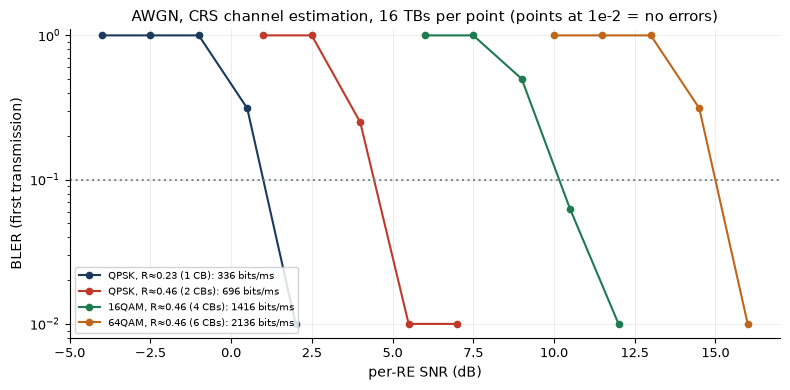

MCS,throughput at 0% BLER (Mb/s),SNR at 10% BLER (dB)
"QPSK, R≈0.23 (1 CB)",0.336,-1.0
"QPSK, R≈0.46 (2 CBs)",0.696,2.5
"16QAM, R≈0.46 (4 CBs)",1.416,7.5
"64QAM, R≈0.46 (6 CBs)",2.136,13.0


In [20]:
def bler(mcs, snr_db, n_tb=16, profile="AWGN", seed=0):
    Qm, C = MCS[mcs]
    r = np.random.default_rng(seed)
    softs, tbs = [], []
    for _ in range(n_tb):
        tb = r.integers(0, 2, tb_size(C)).astype(np.int8)
        cbufs, E = pdsch_encode(tb, Qm, C)
        y, n0 = channel(lp.ofdm_mod(pdsch_modulate(cbufs, E, Qm, 0)), snr_db, profile, r)
        softs.append(pdsch_demod(y, n0, Qm, C, E, 0)[0]); tbs.append(tb)
    lcw = np.concatenate(softs)
    full = np.empty_like(lcw); full[:, INFO], full[:, PIV] = lcw[:, :CODE.k], lcw[:, CODE.k:]
    d, _ = lp.ldpc_decode_batch(CODE, full, iters=20)
    blocks = d[:, INFO].reshape(n_tb, C, -1)
    errs = sum(not lp.crc_ok(np.concatenate([b[:KCB] for b in blocks[t]])) for t in range(n_tb))
    return errs / n_tb

grid_snr = {"QPSK, R≈0.23 (1 CB)": np.arange(-4, 2.1, 1.5), "QPSK, R≈0.46 (2 CBs)": np.arange(1, 7.1, 1.5),
            "16QAM, R≈0.46 (4 CBs)": np.arange(6, 12.1, 1.5), "64QAM, R≈0.46 (6 CBs)": np.arange(10, 16.1, 1.5)}
f, ax = lk.fig((8, 4))
rows = []
for (mcs, ss), col in zip(grid_snr.items(), lk.PALETTE):
    b = [bler(mcs, s_, seed=int(10 * s_) + 1000) for s_ in ss]
    ax.semilogy(ss, np.maximum(b, 1e-2), "o-", color=col, label=f"{mcs}: {tb_size(MCS[mcs][1])} bits/ms")
    s10 = np.interp(-1, -np.array(b, float), ss) if max(b) >= 0.1 >= min(b) else np.nan
    rows.append([mcs, tb_size(MCS[mcs][1]) / 1e3, f"{s10:.1f}"])
ax.axhline(0.1, color=lk.GRAY, ls=":"); ax.set_ylim(8e-3, 1.1)
ax.set_xlabel("per-RE SNR (dB)"); ax.set_ylabel("BLER (first transmission)"); ax.legend(fontsize=7.5)
ax.set_title("AWGN, CRS channel estimation, 16 TBs per point (points at 1e-2 = no errors)")
lk.show(f)
lk.table(rows, ["MCS", "throughput at 0% BLER (Mb/s)", "SNR at 10% BLER (dB)"])

**What you should see.** A staircase of waterfalls, roughly 4–5 dB apart, each step adding about 0.9 bit per RE: the slope of
Shannon's $\log_2(1+\mathrm{SNR})$ (Chapter 21's CQI figure). The curves sit several dB from capacity: the code is short
(384 bits), decoded with min-sum, the channel is estimated from pilots, and, above all, a rate-0.46 transmission punctures
almost half of the parity of a code that was not designed to be punctured. Try `bler("QPSK, R≈0.70 (3 CBs)", 8.0)`: it fails
even at high SNR, because with two thirds of the parity bits missing most check nodes see several erasures and belief
propagation cannot start. That is exactly why the NR base graphs are *raptor-like*: a high-rate core plus degree-1 extension
parity, so that any prefix of the circular buffer is a good code. Monte Carlo with 16 TBs per point is coarse; raise `n_tb`
for smoother curves. The 10% points are the CQI switching thresholds a scheduler would use.

## 6. HARQ: chase combining versus incremental redundancy

When a TB fails, the phone sends a NACK, keeps its soft bits, and the base station retransmits. With **chase combining** each
retransmission repeats the same coded bits (RV 0), so combining only adds SNR (+3 dB for two copies). With **incremental
redundancy** the retransmissions use RV 2, 3, 1: new parity bits from the circular buffer, so the decoder sees a *lower-rate
code*, which is worth more than the SNR. Here: QPSK, three code blocks of $E = 552$ bits (rate 0.70 on the first transmission,
the heavily punctured case of Section 5), AWGN, up to four transmissions.

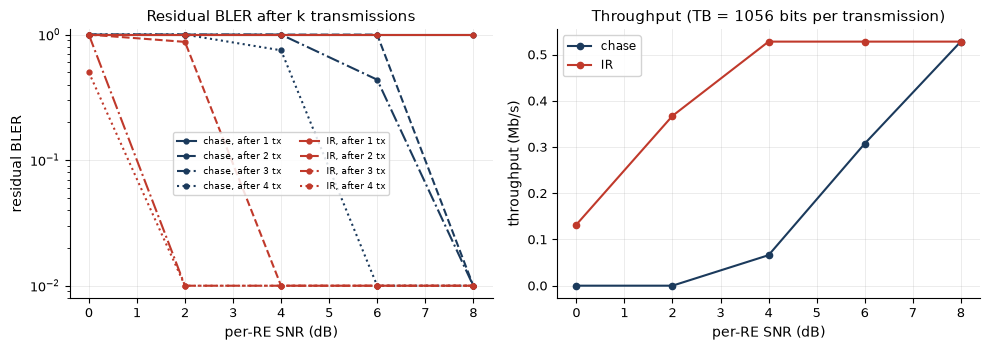

SNR (dB),chase: 1 tx,chase: 2 tx,IR: 1 tx,IR: 2 tx
+0,1.00,1.00,1.00,1.00
+2,1.00,1.00,1.00,0.88
+4,1.00,1.00,1.00,0.00
+6,1.00,1.00,1.00,0.00
+8,1.00,0.00,1.00,0.00


In [22]:
def harq(snr_db, mode, n_tb=16, mcs="QPSK, R≈0.70 (3 CBs)", seed=0, max_tx=4):
    Qm, C = MCS[mcs]
    rvs = (0, 2, 3, 1) if mode == "IR" else (0, 0, 0, 0)
    r = np.random.default_rng(seed)
    data = []
    for _ in range(n_tb):
        tb = r.integers(0, 2, tb_size(C)).astype(np.int8)
        cbufs, E = pdsch_encode(tb, Qm, C)
        data.append((cbufs, E))
    soft = [None] * n_tb
    done_at = np.zeros(n_tb, int)
    for k in range(max_tx):
        act = np.flatnonzero(done_at == 0)
        if len(act) == 0:
            break
        for t in act:
            cbufs, E = data[t]
            y, n0 = channel(lp.ofdm_mod(pdsch_modulate(cbufs, E, Qm, rvs[k])), snr_db, "AWGN", r)
            soft[t] = pdsch_demod(y, n0, Qm, C, E, rvs[k], soft[t])[0]
        lcw = np.concatenate([soft[t] for t in act])
        full = np.empty_like(lcw); full[:, INFO], full[:, PIV] = lcw[:, :CODE.k], lcw[:, CODE.k:]
        d, _ = lp.ldpc_decode_batch(CODE, full, iters=20)
        blocks = d[:, INFO].reshape(len(act), C, -1)
        for j, t in enumerate(act):
            if lp.crc_ok(np.concatenate([b[:KCB] for b in blocks[j]])):
                done_at[t] = k + 1
    p_by = [np.mean((done_at > 0) & (done_at <= k)) for k in range(1, max_tx + 1)]
    ntx = np.where(done_at > 0, done_at, max_tx)
    tput = np.sum(done_at > 0) * tb_size(C) / np.sum(ntx) / 1e3            # Mb/s (one TB per 1 ms transmission)
    return p_by, tput

hs = np.arange(0, 8.1, 2.0)
f, ax = lk.fig("row2", 1, 2)
out = {}
for mode, col in [("chase", lk.NAVY), ("IR", lk.RED)]:
    rr = [harq(s_, mode, seed=int(s_) + 1000) for s_ in hs]
    out[mode] = rr
    for k, ls in zip(range(4), ["-", "--", "-.", ":"]):
        ax[0].semilogy(hs, np.maximum([1 - x[0][k] for x in rr], 1e-2), ls, marker="o", ms=3.5, color=col, label=f"{mode}, after {k + 1} tx")
    ax[1].plot(hs, [x[1] for x in rr], "o-", color=col, label=mode)
ax[0].set_ylim(8e-3, 1.1); ax[0].set_xlabel("per-RE SNR (dB)"); ax[0].set_ylabel("residual BLER"); ax[0].legend(fontsize=6.8, ncol=2)
ax[0].set_title("Residual BLER after k transmissions")
ax[1].set_xlabel("per-RE SNR (dB)"); ax[1].set_ylabel("throughput (Mb/s)"); ax[1].legend(); ax[1].set_title(f"Throughput (TB = {tb_size(3)} bits per transmission)")
lk.show(f)
lk.table([[f"{s_:+.0f}"] + [f"{1 - out[m][i][0][k]:.2f}" for m in ("chase", "IR") for k in (0, 1)] for i, s_ in enumerate(hs)],
         ["SNR (dB)", "chase: 1 tx", "chase: 2 tx", "IR: 1 tx", "IR: 2 tx"], title="Residual BLER")

**What you should see.** The first transmission fails for both schemes at every SNR shown (the punctured rate-0.70 code of
Section 5). Chase combining only adds energy to the *same* punctured bits: two copies (3 dB) rescue it only at 8 dB. IR's
second transmission (RV 2 starts at position 576, exactly where RV 0 stopped reading parity) delivers 552 *new* parity bits:
the decoder now sees a rate-0.35 code and decodes at about 4 dB, and RVs 3 and 1 push the threshold lower still. With a
puncture-friendly code (NR's base graphs) chase would also gain its 3 dB per doubling, but IR still wins because a lower-rate
code is worth more than more SNR at a fixed rate. That is why LTE and NR use IR with the RV order 0, 2, 3, 1 (Chapter 15's
worked example on chase versus IR makes the same comparison in capacity terms).

### Try it yourself 6.1
With $N_{cb} = 1152$, at which buffer position does RV 3 start?

In [24]:
answer_6_1 = None
lk.check("6.1 k0 for RV 3, Ncb = 1152", answer_6_1, lp.rv_start(3, 1152), atol=0)

[TODO] 6.1 k0 for RV 3, Ncb = 1152: not attempted yet: replace the None with your answer

## Key takeaways
* The LTE subframe is 14 symbols × 12 subcarriers per RB; control, CRS and sync signals take roughly a fifth of the REs before any data.
* Zadoff–Chu PSS (3 roots) and m-sequence SSS (168 × 2) give timing, frequency and the 504 cell identities in three correlations.
* Frequency offsets of a few kHz break a coherent PSS correlation; splitting it fixes that and yields the CFO estimate.
* The PDSCH chain is CRC → segmentation → LDPC → circular buffer → RV → interleave → scramble → QAM → OFDM, and the
  receiver undoes it with soft bits, accumulating LLRs in the circular buffer.
* Each MCS step of about 4–5 dB adds about one bit per RE; link adaptation targets 10% BLER on the first transmission.
* Rate matching punctures parity: the mother code must be designed for it (NR's raptor-like base graphs).
* Incremental redundancy turns retransmissions into a lower-rate code and beats chase combining.

## Going further (hardware: USRP B200 / GNU Radio)
* Capture 20 ms of a real LTE carrier at 1.92 MS/s with `gnuradio/gr01_spectrum_iq_capture.py` (centre it on the carrier;
  the PSS/SSS sit on the central 62 subcarriers whatever the bandwidth) and run `cell_search` on it: you will find the PCIs
  of the cells around you and your B200's frequency error. Compare with a phone's engineering screen.
* Transmit the PDSCH subframes of Section 4 from the B200 through a 30 dB attenuator into its own receiver and decode them.

## Exercises
1. **(Warm-up)** Show that the PSS for roots 29 and 34 are complex conjugates of each other ($29 + 34 = 63$), and explain why
   that lets a receiver compute two of the three PSS correlations for the price of one.
2. **(Core)** Add CRS-based SINR measurement and implement link adaptation: choose the MCS from the measured SNR and the 10% points
   of Section 5, and measure throughput against SNR.
3. **(Core)** Implement the NR rule that the first $2Z_c$ systematic bits are never transmitted, and see how RV 0 changes.
4. **(Stretch)** Replace the cell search's fixed two-cell assumption with a detection threshold and measure the false-alarm rate on noise only.

In [26]:
lk.summary()

[good] Lab 27 finished in 50.3 s. Self-checks: 0 passed, 0 failed, 4 still to do.